In [ ]:
# INITIAL SETTINGS

!pip install -U kaleido
# basic python libraries
import os
import pickle
import warnings
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
!pip install catboost
from catboost import CatBoostRegressor
# hyperparameter tuning
!pip install optuna
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate
# PyTorch for NN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# SHAP for explainability
import shap

warnings.filterwarnings('ignore')
seed = 2006
np.random.seed(seed)
torch.manual_seed(seed)

# paths for saving of results
base_path = '/content/drive/MyDrive/Concrete Compressive Strength Prediction'
cleaned_data = os.path.join(base_path, '01_Dataset', 'Processed', 'df_clean.csv')
processed_dir = os.path.join(base_path, '01_Dataset', 'Processed')
models_baseline = os.path.join(base_path, '04_Models', 'baseline')
models_tuned  = os.path.join(base_path, '04_Models','tuned')
models_dl      = os.path.join(base_path, '04_Models','ANN')
metrics_dir    = os.path.join(base_path, '04_Results','metrics')
optuna_dir     = os.path.join(base_path, '04_Results','optuna_studies')
plots_perf     = os.path.join(base_path, '04_Results','plots','model_performance')
plots_shap     = os.path.join(base_path, '04_Results','plots','shap')
# create if not exist
for d in [processed_dir, models_baseline, models_tuned, models_dl,
          metrics_dir, optuna_dir, plots_perf, plots_shap]:
    os.makedirs(d, exist_ok=True)

In [ ]:
df = pd.read_csv(cleaned_data)
df.shape

(1005, 10)

In [ ]:
df.duplicated().value_counts()

,count
False,1005


In [ ]:
df.isna().sum()

,0
cement,0
blast_furnace_slag,0
fly_ash,0
water,0
superplasticizer,0
coarse_aggregate,0
fine_aggregate,0
age,0
concrete_compressive_strength,0
water_cement_ratio,0


In [ ]:
df.sample(5)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,water_cement_ratio
441,173.8,93.4,159.9,172.3,9.7,1007.2,746.6,100,50.94,0.991369
674,203.5,305.3,0.0,203.5,0.0,963.4,630.0,28,41.68,1.000000
581,236.0,0.0,0.0,194.0,0.0,968.0,885.0,3,6.47,0.822034
429,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,56,31.72,0.875460
833,322.0,149.0,0.0,186.0,8.0,951.0,709.0,28,52.42,0.577640


In [ ]:
# Sepratate Features & lables
X = df.drop(columns=['concrete_compressive_strength'])
y = df['concrete_compressive_strength']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (1005, 9), y shape: (1005,)


In [ ]:
X.columns

Index(['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate ', 'age', 'water_cement_ratio'],
      dtype='object')

In [ ]:
y.name

'concrete_compressive_strength'

In [ ]:
# Train/Test Spli -> 80 / 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 804, Test: 201


In [ ]:
# StandardScaler
scaler = StandardScaler()
# create a copy scaling not required for tree & boosting algos
X_train_scal = X_train.copy()
X_test_scal = X_test.copy()
X_train_scaled = scaler.fit_transform(X_train_scal)
X_test_scaled = scaler.transform(X_test_scal)
# keep as DF also for future reference
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
# save for future reference as train.csv & test.csv
pd.concat([X_train,y_train],axis=1).to_csv(os.path.join(processed_dir,'train.csv'),index=False)
pd.concat([X_test,y_test],axis=1).to_csv(os.path.join(processed_dir,'test.csv'),index=False)
pd.concat([X_train_scaled,y_test],axis=1).to_csv(os.path.join(processed_dir,'train_scaled.csv'),index=False)
pd.concat([X_test_scaled,y_test],axis=1).to_csv(os.path.join(processed_dir,'test_scaled.csv'),index=False)

In [ ]:
X_train_scaled.mean() # scaling effective , all approx 0

,0
cement,2.076835e-16
blast_furnace_slag,3.093159e-17
fly_ash,5.302558e-17
water,1.120165e-15
superplasticizer,8.837596e-17
coarse_aggregate,2.121023e-16
fine_aggregate,-5.766532e-16
age,6.849137e-17
water_cement_ratio,-1.325639e-16


In [ ]:
X_train_scaled.std() # scaling effective , all approx 1

,0
cement,1.000622
blast_furnace_slag,1.000622
fly_ash,1.000622
water,1.000622
superplasticizer,1.000622
coarse_aggregate,1.000622
fine_aggregate,1.000622
age,1.000622
water_cement_ratio,1.000622


In [ ]:
# save the scaler
with open(os.path.join(processed_dir,'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

In [ ]:
def evaluate_model(model, X_train,y_train,X_test,y_test,cv=5):
  y_pred = model.predict(X_test)
  r2 = r2_score(y_test,y_pred)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  mae = mean_absolute_error(y_test,y_pred)
  cv_scores = cross_val_score(model,X_train,y_train,cv=cv,scoring='r2')
  return {
      'R2': r2,
      'RMSE': rmse,
      'MAE': mae,
      'CV_R2_mean': cv_scores.mean(),
      'CV_R2_std': cv_scores.std()
  }

# save the metric values
def save_metrics(metrics_dict,filename,append=True):
  df = pd.DataFrame([metrics_dict])
  mode = 'a' if append and os.path.exists(filename) else 'w'
  header = not os.path.exists(filename) or mode == 'w'
  df.to_csv(filename,mode=mode,header=header,index=False)

**Baseline Models** : i.e Models with default hyperparameters

In [ ]:
# Models requiring scaled data i.e Gradient Based & distance based algos
scaled_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=seed),              # L2 regularization
    'Lasso': Lasso(random_state=seed, max_iter=5000),   # L1 regularization
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(verbose=True)
}

# Tree & boosting algos, no need for scaling
unscaled_models = {
    'DecisionTree': DecisionTreeRegressor(random_state=seed),
    'RandomForest': RandomForestRegressor(random_state=seed, verbose=1),
    'GradientBoosting': GradientBoostingRegressor(random_state=seed, verbose=1),
    'XGBoost': xgb.XGBRegressor(random_state=seed, verbosity=1),
    'LightGBM': lgb.LGBMRegressor(random_state=seed, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=seed, verbose=100)
}

baseline_results = []

# 1. Scaled Models
for name, model in scaled_models.items():
  print(f"-"*100)
  print(f"\nTraining {name} Started")
  start_time = time.perf_counter()
  model.fit(X_train_scaled,y_train)
  end_time = time.perf_counter()
  elapsed_time = end_time - start_time
  # helper function called
  metrics = evaluate_model(model,X_train_scaled,y_train,X_test_scaled,y_test)
  metrics['Model'] = name
  metrics['Type'] = 'Baseline'
  metrics['Scaled'] = True
  metrics['Training Time (s)'] = round(elapsed_time,4)
  # helper function called below
  baseline_results.append(metrics)
  # save the results
  with open(os.path.join(models_baseline, f'{name}.pkl'), 'wb') as f:
    pickle.dump(model,f)
  save_metrics(metrics, os.path.join(metrics_dir, 'baseline_results.csv'))
  print(f"\nTraining {name} Finished")
  print(f"\nTraining Time: {elapsed_time}")
  print(f"-"*100)



# 2) Unscaled models
for name, model in unscaled_models.items():
  print(f"-"*100)
  print(f"\nTraining {name} Started")
  start_time = time.perf_counter()
  model.fit(X_train, y_train)
  end_time = time.perf_counter()
  elapsed_time = end_time - start_time
  metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
  metrics['Model'] = name
  metrics['Type'] = 'Baseline'
  metrics['Scaled'] = False
  metrics['Training Time (s)'] = round(elapsed_time,4)
  baseline_results.append(metrics)
  with open(os.path.join(models_baseline, f'{name}.pkl'), 'wb') as f:
      pickle.dump(model, f)
  save_metrics(metrics, os.path.join(metrics_dir, 'baseline_results.csv'))
  print(f"\nTraining {name} Finished")
  print(f"\nTraining Time: {elapsed_time}")
  print(f"-"*100)

----------------------------------------------------------------------------------------------------

Training LinearRegression Started

Training LinearRegression Finished

Training Time: 0.006152412999654189
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

Training Ridge Started

Training Ridge Finished

Training Time: 0.004777844000273035
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

Training Lasso Started

Training Lasso Finished

Training Time: 0.004008839001471642
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

Training KNN

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: 


Training RandomForest Finished

Training Time: 0.7547433050003747
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

Training GradientBoosting Started
      Iter       Train Loss   Remaining Time 
         1         237.9561            0.38s
         2         209.1623            0.37s
         3         186.6936            0.36s
         4         166.3654            0.35s
         5         149.7892            0.36s
         6         136.3765            0.36s
         7         125.1034            0.35s
         8         114.6205            0.34s
         9         103.9377            0.33s
        10          94.9661            0.33s
        20          51.1011            0.34s
        30          34.7682            0.32s
        40          26.9395            0.27s
        50          22.6738            0.23s
        60          

In [ ]:
# Display baseline summary & select top candidates for tuning
df_baseline = pd.DataFrame(baseline_results)
df_baseline_sorted = df_baseline.sort_values('R2', ascending=False)
print("\nBaseline performance (sorted by R2):")
print(df_baseline_sorted[['Model', 'R2', 'RMSE', 'MAE', 'CV_R2_mean']].round(4))

# Select top 5 for tuning
top5 = df_baseline_sorted.head(5)['Model'].tolist()
print(f"\nTop candidates for tuning: {top5}")


Baseline performance (sorted by R2):
               Model      R2     RMSE     MAE  CV_R2_mean
10          CatBoost  0.9324   4.0119  2.6770      0.9341
9           LightGBM  0.9193   4.3853  2.9025      0.9246
8            XGBoost  0.9193   4.3855  2.9157      0.9190
6       RandomForest  0.8984   4.9194  3.4757      0.9050
7   GradientBoosting  0.8945   5.0134  3.5887      0.9038
5       DecisionTree  0.8531   5.9169  4.0984      0.8311
3                KNN  0.6900   8.5941  6.6969      0.6615
4                SVR  0.5871   9.9178  7.8911      0.5928
1              Ridge  0.5439  10.4237  8.0098      0.5940
0   LinearRegression  0.5434  10.4297  8.0031      0.5938
2              Lasso  0.5141  10.7596  8.6807      0.5477

Top candidates for tuning: ['CatBoost', 'LightGBM', 'XGBoost', 'RandomForest', 'GradientBoosting']


**Hyper parameter tuning using OPTUNA**

In [ ]:
# 80/20 split used for boosting algos to enable early stopping
X_train_boost, X_val_boost, y_train_boost, y_val_boost = train_test_split(
    X_train, y_train, test_size=0.2, random_state=seed
)
print(f"Boosting ALgos set:")
print(f"Training set: {X_train_boost.shape[0]} samples")
print(f"Validation set: {X_val_boost.shape[0]} samples")

Boosting ALgos set:
Training set: 643 samples
Validation set: 161 samples


In [ ]:
X_train_boost.head(5) # confirmed, using unscaled sets

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,water_cement_ratio
534,272.8,181.9,0.0,185.7,0.0,1012.4,714.3,7,0.680718
215,229.7,0.0,118.2,195.2,6.1,1028.1,757.6,3,0.849804
1001,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,0.608318
569,252.5,0.0,0.0,185.7,0.0,1111.6,784.3,7,0.735446
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,0.685714


**Hyperparameter Tuning**

In [ ]:
# OPTUNA study run funct & loop

n_trials = 75

def run_optuna_tuning(model_name, X_train_cv, y_train_cv, X_val_cv, y_val_cv,
                      X_train_full,y_train_full,X_test_eval, y_test_eval,
                      n_trials=n_trials):
    print(f"\n{'-'*100}")
    print(f"Tuning {model_name} with {n_trials} trials")
    print(f"{'-'*100}")

    # early stopping?
    use_early_stop = model_name in ['XGBoost', 'LightGBM', 'CatBoost']

    def objective(trial):
        # hyperparameter search space
        if model_name == 'RandomForest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
            }
            model = RandomForestRegressor(random_state=seed, n_jobs=-1, **params)
            # Use 5-fold CV on training data
            return cross_val_score(model, X_train_cv, y_train_cv, cv=5, scoring='r2').mean()

        elif model_name == 'GradientBoosting':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0)
            }
            model = GradientBoostingRegressor(random_state=seed, **params)
            return cross_val_score(model, X_train_cv, y_train_cv, cv=5, scoring='r2').mean() # average value

        elif model_name == 'XGBoost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
            }
            model = xgb.XGBRegressor(random_state=seed, n_jobs=-1, verbosity=0, early_stopping_rounds=15,
                                     **params)
            model.fit(
                X_train_cv, y_train_cv,
                eval_set=[(X_val_cv, y_val_cv)],
                verbose=False
            )
            return r2_score(y_val_cv, model.predict(X_val_cv))

        elif model_name == 'LightGBM':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'num_leaves': trial.suggest_int('num_leaves', 10, 100),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
            }
            model = lgb.LGBMRegressor(random_state=seed, n_jobs=-1, verbose=-1, **params)
            model.fit(
                X_train_cv, y_train_cv,
                eval_set=[(X_val_cv, y_val_cv)],
                callbacks=[lgb.early_stopping(15), lgb.log_evaluation(0)]
            )
            return r2_score(y_val_cv, model.predict(X_val_cv))

        elif model_name == 'CatBoost':
            params = {
                'iterations': trial.suggest_int('iterations', 100, 400),
                'depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
                'border_count': trial.suggest_int('border_count', 32, 255)
            }
            model = CatBoostRegressor(random_state=seed, verbose=False, **params)
            model.fit(
                X_train_cv, y_train_cv,
                eval_set=(X_val_cv, y_val_cv),
                early_stopping_rounds=15,
                verbose=False
            )
            return r2_score(y_val_cv, model.predict(X_val_cv))

        else:
            raise ValueError(f"Model not identified")

    # run OPTUNA study
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # Save study object
    study_path = os.path.join(optuna_dir, f'{model_name}_study.pkl')
    with open(study_path, 'wb') as f:
        pickle.dump(study, f)

    # Generate and save Optuna perf plots
    try:
        fig1 = plot_optimization_history(study)
        fig1.write_image(os.path.join(plots_perf, f'{model_name}_optim_history.png'))
        fig2 = plot_param_importances(study)
        fig2.write_image(os.path.join(plots_perf, f'{model_name}_param_importance.png'))
        fig3 = plot_parallel_coordinate(study)
        fig3.write_image(os.path.join(plots_perf, f'{model_name}_parallel_coord.png'))
    except Exception as e:
        print(f"Plot generation failed for {model_name}: {e}")

    # Retrain with best params on full X_train
    best_params = study.best_params
    print(f"Best params for {model_name}: {best_params}")

    if model_name == 'RandomForest':
        final_model = RandomForestRegressor(random_state=seed, n_jobs=-1, **best_params)
    elif model_name == 'GradientBoosting':
        final_model = GradientBoostingRegressor(random_state=seed, **best_params)
    elif model_name == 'XGBoost':
        final_model = xgb.XGBRegressor(random_state=seed, n_jobs=-1, verbosity=0, **best_params)
    elif model_name == 'LightGBM':
        final_model = lgb.LGBMRegressor(random_state=seed, n_jobs=-1, verbose=-1, **best_params)
    elif model_name == 'CatBoost':
        final_model = CatBoostRegressor(random_state=seed, verbose=False, **best_params)
    final_model.fit(X_train_full,y_train_full)

    # Evaluate on test data
    metrics = evaluate_model(final_model, X_train_cv, y_train_cv, X_test_eval, y_test_eval)
    metrics['Model'] = model_name
    metrics['Type'] = 'Tuned'
    metrics['Scaled'] = False
    metrics['Best_Params'] = str(best_params)

    # Save tuned model
    model_path = os.path.join(models_tuned, f'{model_name}_tuned.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(final_model, f)

    # Save metrics to tuned_results.csv
    save_metrics(metrics, os.path.join(metrics_dir, 'tuned_results.csv'))

    return best_params, study, metrics


# run tuning for all 5
top5 = ['CatBoost', 'LightGBM', 'XGBoost', 'RandomForest', 'GradientBoosting']
tuned_metrics = {}

for model_name in top5:
    # For boosted models, using validation split
    if model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
        X_tr = X_train_boost
        y_tr = y_train_boost
        X_val = X_val_boost
        y_val = y_val_boost
    else:
        # For RF and GB, using full X_train
        X_tr = X_train
        y_tr = y_train
        X_val = None
        y_val = None

    # pass arguments to the func
    best_params, study, metrics = run_optuna_tuning(
        model_name=model_name,
        X_train_cv=X_tr,
        y_train_cv=y_tr,
        X_val_cv=X_val,
        y_val_cv=y_val,
        X_train_full=X_train,
        y_train_full = y_train,
        X_test_eval=X_test,
        y_test_eval=y_test,
        n_trials=n_trials
    )
    tuned_metrics[model_name] = metrics
    print(f"\n{model_name} Best CV/Val R2 {study.best_value:.4f}")
    print(f"{model_name} Test R2 {metrics['R2']:.4f}")

print("\nTuning completed for all 5 candidates.")

[I 2026-08-25 16:41:43,228] A new study created in memory with name: no-name-cda78ce8-fcce-485d-b149-ab6cd217b298



----------------------------------------------------------------------------------------------------
Tuning CatBoost with 75 trials
----------------------------------------------------------------------------------------------------


  0%|          | 0/75 [00:00<?, ?it/s]

[I 2026-08-25 16:41:47,321] Trial 0 finished with value: 0.9487629752586824 and parameters: {'iterations': 172, 'depth': 10, 'learning_rate': 0.08647416116879585, 'l2_leaf_reg': 0.011526502825909514, 'border_count': 197}. Best is trial 0 with value: 0.9487629752586824.
[I 2026-08-25 16:41:54,081] Trial 1 finished with value: 0.9428127724388379 and parameters: {'iterations': 318, 'depth': 9, 'learning_rate': 0.02726916134796555, 'l2_leaf_reg': 1.0628191243158438, 'border_count': 208}. Best is trial 0 with value: 0.9487629752586824.
[I 2026-08-25 16:41:54,592] Trial 2 finished with value: 0.8632410150783405 and parameters: {'iterations': 199, 'depth': 5, 'learning_rate': 0.014172767304122967, 'l2_leaf_reg': 0.4772755803100758, 'border_count': 165}. Best is trial 0 with value: 0.9487629752586824.
[I 2026-08-25 16:42:04,800] Trial 3 finished with value: 0.9259460928101609 and parameters: {'iterations': 217, 'depth': 10, 'learning_rate': 0.022732363269834577, 'l2_leaf_reg': 0.97586031484082

[I 2026-08-25 16:44:19,107] A new study created in memory with name: no-name-c86758b6-89ca-43f6-8e5a-ff5cfc23d695


...

[I 2026-08-25 16:45:10,262] Trial 0 finished with value: 0.8751056395349028 and parameters: {'n_estimators': 110, 'max_depth': 20, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 0 with value: 0.8751056395349028.
[I 2026-08-25 16:45:13,403] Trial 1 finished with value: 0.8693434111572156 and parameters: {'n_estimators': 124, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.8751056395349028.
[I 2026-08-25 16:45:15,702] Trial 2 finished with value: 0.8401138484098934 and parameters: {'n_estimators': 199, 'max_depth': 10, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8751056395349028.
[I 2026-08-25 16:45:17,766] Trial 3 finished with value: 0.8740855455635632 and parameters: {'n_estimators': 168, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.875105639534902

[I 2026-08-25 16:50:46,163] A new study created in memory with name: no-name-8d4d5a42-84b0-47f8-9bb9-8a3e74ff9b49



RandomForest Best CV/Val R2 0.9046
RandomForest Test R2 0.8988

----------------------------------------------------------------------------------------------------
Tuning GradientBoosting with 75 trials
----------------------------------------------------------------------------------------------------


  0%|          | 0/75 [00:00<?, ?it/s]

[I 2026-08-25 16:50:48,329] Trial 0 finished with value: 0.927055819108023 and parameters: {'n_estimators': 110, 'learning_rate': 0.27252031110633756, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 8, 'subsample': 0.8898617939362552}. Best is trial 0 with value: 0.927055819108023.
[I 2026-08-25 16:50:52,914] Trial 1 finished with value: 0.9247083229184005 and parameters: {'n_estimators': 242, 'learning_rate': 0.02726916134796555, 'max_depth': 9, 'min_samples_split': 16, 'min_samples_leaf': 4, 'subsample': 0.6755460909638882}. Best is trial 0 with value: 0.927055819108023.
[I 2026-08-25 16:50:54,509] Trial 2 finished with value: 0.9222656471664189 and parameters: {'n_estimators': 75, 'learning_rate': 0.09754763301859416, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 9, 'subsample': 0.6965782833174579}. Best is trial 0 with value: 0.927055819108023.
[I 2026-08-25 16:50:58,306] Trial 3 finished with value: 0.9300075136895505 and parameters: {'n_estimators': 237,

In [ ]:
# plot utility didnt worked during optuna search
# regenerating using othe library
import plotly.io as pio
import os
pio.renderers.default = 'colab'

# the top 5
top_candidates = ['CatBoost', 'LightGBM', 'XGBoost', 'RandomForest', 'GradientBoosting']

# Ensure the output directory exists
os.makedirs(plots_perf, exist_ok=True)

for model_name in top_candidates:
    study_path = os.path.join(optuna_dir, f'{model_name}_study.pkl')

    if not os.path.exists(study_path):
        print(f"Study file not found for {model_name}, skipping.")
        continue

    # Load the study object
    with open(study_path, 'rb') as f:
        study = pickle.load(f)

    print(f"\nGenerating diagnostic plots for {model_name}")
    print(f"Best validation R2 from tuning: {study.best_value:.4f}")

    # Generate the three figures
    fig1 = plot_optimization_history(study)
    fig2 = plot_param_importances(study)
    fig3 = plot_parallel_coordinate(study)

    # Display inline in the notebook
    print("Optimization history:")
    fig1.show()
    print("Parameter importance:")
    fig2.show()
    print("Parallel coordinate plot:")
    fig3.show()

    # Save to disk
    base_name = model_name
    png_suffix = '.png'
    html_suffix = '.html'

    try:
        # Try saving as PNG
        fig1.write_image(os.path.join(plots_perf, f'{base_name}_optim_history{png_suffix}'))
        fig2.write_image(os.path.join(plots_perf, f'{base_name}_param_importance{png_suffix}'))
        fig3.write_image(os.path.join(plots_perf, f'{base_name}_parallel_coord{png_suffix}'))
        print(f"PNG files saved for {model_name}")
    except Exception as e:
        # Fallback: save as interactive HTML
        print(f"Could not save PNG (kaleido missing or error). Saving HTML instead for {model_name}.")
        fig1.write_html(os.path.join(plots_perf, f'{base_name}_optim_history{html_suffix}'))
        fig2.write_html(os.path.join(plots_perf, f'{base_name}_param_importance{html_suffix}'))
        fig3.write_html(os.path.join(plots_perf, f'{base_name}_parallel_coord{html_suffix}'))
        print(f"HTML files saved for {model_name}")

print("\nAll diagnostic plots have been generated and saved.")


Generating diagnostic plots for CatBoost
Best validation R2 from tuning: 0.9527
Optimization history:


Parameter importance:


Parallel coordinate plot:


Could not save PNG (kaleido missing or error). Saving HTML instead for CatBoost.
HTML files saved for CatBoost

Generating diagnostic plots for LightGBM
Best validation R2 from tuning: 0.9498
Optimization history:


Parameter importance:


...

Parallel coordinate plot:


Could not save PNG (kaleido missing or error). Saving HTML instead for RandomForest.
HTML files saved for RandomForest

Generating diagnostic plots for GradientBoosting
Best validation R2 from tuning: 0.9349
Optimization history:


Parameter importance:


Parallel coordinate plot:


Could not save PNG (kaleido missing or error). Saving HTML instead for GradientBoosting.
HTML files saved for GradientBoosting

All diagnostic plots have been generated and saved.


In [ ]:
# model comparison & final selection

# Load baseline and tuned results
baseline_path = os.path.join(metrics_dir, 'baseline_results.csv')
tuned_path = os.path.join(metrics_dir, 'tuned_results.csv')

baseline_df = pd.read_csv(baseline_path)
tuned_df = pd.read_csv(tuned_path)

# remove duplicate entries
#baseline_df = baseline_df.drop_duplicates(subset=['Model', 'Type'], keep='first')
#tuned_df = tuned_df.drop_duplicates(subset=['Model', 'Type'], keep='first')

# ensure numeric cols are float
numeric_cols = ['R2', 'RMSE', 'MAE', 'CV_R2_mean', 'CV_R2_std']
for df in [baseline_df, tuned_df]:
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# combine & sort
all_results = pd.concat([baseline_df, tuned_df], ignore_index=True)
all_results = all_results.dropna(subset=['R2'])  # remove rows with invalid R²
all_results_sorted = all_results.sort_values('R2', ascending=False)

# add generalization gap
all_results_sorted['Gap'] = all_results_sorted['CV_R2_mean'] - all_results_sorted['R2']

# Save the full comparison table
final_path = os.path.join(metrics_dir, 'final_comparison.csv')
all_results_sorted.to_csv(final_path, index=False)

print("\nTop 10 models (R²):")
print(all_results_sorted[['Model', 'Type', 'R2', 'RMSE', 'CV_R2_mean', 'Gap']].head(10).round(4))

# select the best model
# 1) Filter to models with R² > 0.92 and Gap < 0.02 (if any)
candidates = all_results_sorted[(all_results_sorted['R2'] > 0.92) & (all_results_sorted['Gap'] < 0.02)]

if not candidates.empty:
    # Among candidates, pick the one with highest R² (or lowest RMSE)
    best_model = candidates.sort_values('R2', ascending=False).iloc[0]
else:
    # Fallback: just take the highest R²
    best_model = all_results_sorted.iloc[0]

best_model_name = best_model['Model']
best_model_type = best_model['Type']
best_model_r2 = best_model['R2']
best_model_gap = best_model['Gap']

print("\n" + "="*60)
print("Final Model Selection")
print("="*60)
print(f"Selected model: {best_model_name} ({best_model_type})")
print(f"Test R²: {best_model_r2:.4f}")
print(f"CV/Val R²: {best_model['CV_R2_mean']:.4f}")
print(f"Generalization Gap: {best_model_gap:.4f}")
print("="*60)

# save best model infor for SHAP
best_info = {
    'Model': best_model_name,
    'Type': best_model_type,
    'Scaled': best_model.get('Scaled', False),  # default False if missing
    'R2': best_model['R2'],
    'RMSE': best_model['RMSE'],
    'MAE': best_model.get('MAE', None)
}
with open(os.path.join(metrics_dir, 'best_model_info.pkl'), 'wb') as f:
    pickle.dump(best_info, f)

print(f"\nBest model info saved to {os.path.join(metrics_dir, 'best_model_info.pkl')}")


Top 10 models (R²):
               Model      Type      R2    RMSE  CV_R2_mean     Gap
10          CatBoost  Baseline  0.9324  4.0119      0.9341  0.0016
11          CatBoost     Tuned  0.9304  4.0724      0.8966 -0.0338
15  GradientBoosting     Tuned  0.9295  4.0976      0.9349  0.0054
13           XGBoost     Tuned  0.9203  4.3578      0.9034 -0.0169
9           LightGBM  Baseline  0.9193  4.3853      0.9246  0.0053
8            XGBoost  Baseline  0.9193  4.3855      0.9190 -0.0003
12          LightGBM     Tuned  0.9179  4.4223      0.8964 -0.0215
14      RandomForest     Tuned  0.8988  4.9114      0.9046  0.0059
6       RandomForest  Baseline  0.8984  4.9194      0.9050  0.0065
7   GradientBoosting  Baseline  0.8945  5.0134      0.9038  0.0093

Final Model Selection
Selected model: CatBoost (Baseline)
Test R²: 0.9324
CV/Val R²: 0.9341
Generalization Gap: 0.0016

Best model info saved to /content/drive/MyDrive/Concrete Compressive Strength Prediction/04_Results/metrics/best_model_in

Loading CatBoost (Baseline) for SHAP analysis...
SHAP values computed.
Global summary plot saved.
Dependence plot saved for age
Dependence plot saved for water_cement_ratio


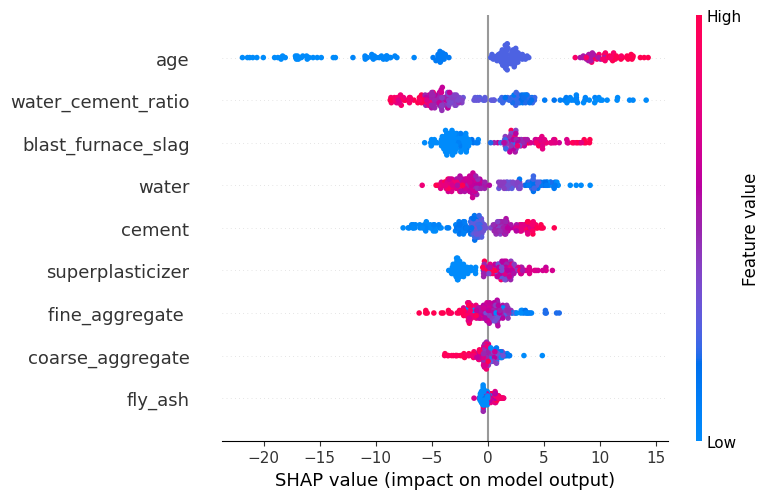

<Figure size 800x600 with 0 Axes>

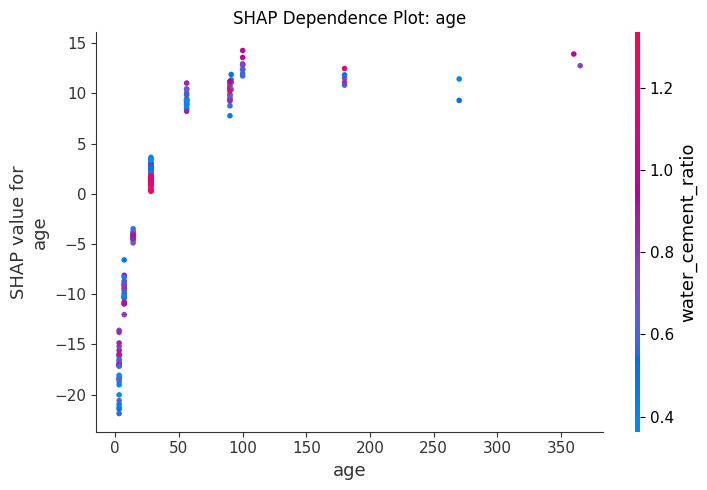

<Figure size 800x600 with 0 Axes>

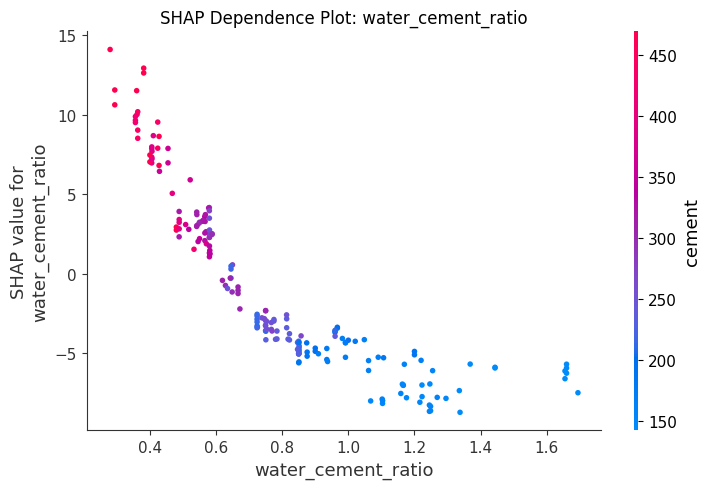

In [ ]:
# explainable AI technique applied

# load best model info
best_info_path = os.path.join(metrics_dir, 'best_model_info.pkl')
with open(best_info_path, 'rb') as f:
    best_info = pickle.load(f)

model_name = best_info['Model']
model_type = best_info['Type']
use_scaled = best_info.get('Scaled', False)

print(f"Loading {model_name} ({model_type}) for SHAP analysis...")

# load the model
if model_type == 'Baseline':
    model_path = os.path.join(models_baseline, f'{model_name}.pkl')
else:
    model_path = os.path.join(models_tuned, f'{model_name}_tuned.pkl')

with open(model_path, 'rb') as f:
    model = pickle.load(f)

# prepare data
X_shap = X_test if not use_scaled else X_test_scaled
feature_names = X_shap.columns.tolist()

# create TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print("SHAP values computed.")

#
# beeSwarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(os.path.join(plots_shap, 'global_summary_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.plot()
print("Global summary plot saved.")

# depenedence plots for top2 Features
feature_importance = np.abs(shap_values).mean(axis=0)
top_feature_indices = np.argsort(feature_importance)[::-1][:2]
top_feature_names = [feature_names[i] for i in top_feature_indices]

for idx, feat_name in zip(top_feature_indices, top_feature_names):
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(idx, shap_values, X_shap, feature_names=feature_names, show=False)
    plt.title(f'SHAP Dependence Plot: {feat_name}')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_shap, f'dependence_{feat_name}.png'), dpi=150)
    plt.plot()
    print(f"Dependence plot saved for {feat_name}")